# MBG Smart Plate: Sistem Personalisasi Menu Gizi Berbasis Web untuk Mendukung Program Makan Bergizi Gratis

## Permasalahan/Pertanyaan Bisnis

**Latar Belakang:**
Program Makan Bergizi Gratis (MBG) menghadapi tantangan dalam personalisasi gizi. Saat ini, sistem cenderung memberikan menu generik tanpa mempertimbangkan kondisi fisik unik setiap siswa (stunting, gizi normal, atau overweight). Solusi yang ditawarkan adalah sistem personalisasi menu otomatis berdasarkan klasifikasi kondisi fisik berdasarkan status gizi siswa.

- Pertanyaan 1 (Fitur Gizi Signifikan): Apa saja parameter gizi yang paling berpengaruh/sebaiknya dijadikan patokan utama dalam menyusun rekomendasi menu personalisasi untuk siswa dengan status gizi berbeda?

- Pertanyaan 2 (Fitur Dominan): Variabel apa yang paling dominan mempengaruhi klasifikasi status gizi siswa?

- Pertanyaan 3 (Distribusi dan Prevalensi): Bagaimana distribusi status gizi siswa? Berapa persentase siswa yang memerlukan intervensi gizi prioritas (underweight dan overweight)? Kelompok usia mana yang diprioritaskan?

- Pertanyaan 4 (Rekomendasi Gizi): Berdasarkan data TKPI, bahan pangan apa saja yang memiliki kandungan gizi untuk menaikkan berat badan (kategori Underweight), mengoptimalkan berat badan (kategori normal), dan menurunkan berat badan (kategori Overweight)?

- Pertanyaan 5 (Model Klasifikasi): Bagaimana performa model machine learning dalam mengklasifikasikan status gizi siswa (Underweight, Normal, Overweight) berdasarkan data antropometri (usia, jenis kelamin, tinggi badan, berat badan)? Algoritma mana yang memberikan akurasi tertinggi?

## Import Packages/Library yang Digunakan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
import joblib

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.style.use('seaborn-v0_8-darkgrid')

## Data Wrangling

### Gathering Data

In [3]:
# 1. Dataset Antropometri (BMI)
url_bmi = 'https://docs.google.com/spreadsheets/d/1ub4EZ50clYbgw_yi0HQX-2OD99cXmMa4-NxrgX3tn88/export?format=csv'
df_bmi = pd.read_csv(url_bmi)

print("\nDataset Antropometri")
print(f"Dataset memiliki {df_bmi.shape[0]} baris dan {df_bmi.shape[1]} kolom")
print("5 Baris Pertama:")
df_bmi.head()


Dataset Antropometri
Dataset memiliki 30000 baris dan 6 kolom
5 Baris Pertama:


,umur,jenis_kelamin,tinggi_cm,berat_kg,bmi,label
0,11,P,140.7,34.5,17.41,Normal
1,10,L,135.9,29.5,15.98,Normal
2,11,P,138.9,36.2,18.80,Gemuk
3,10,P,131.9,28.5,16.37,Normal
4,6,L,117.0,17.3,12.66,Kurus


In [4]:
## Tahap Menambah Noise Data (Simulasi Data Kotor)
# 1. Dataset Antropometri (BMI)
# Menghapus kolom BMI (akan dihitung ulang nanti)
noBMI_df = df_bmi.drop('bmi', axis=1).copy()
print(f"\nData awal shape: {noBMI_df.shape}")

noisy_data_df = noBMI_df.copy()
num_original_rows = len(noisy_data_df)

# 1) Menambah Missing Values
num_missing_values = 200
missing_indices = np.random.choice(num_original_rows, num_missing_values, replace=False)
columns_for_nan = ['umur', 'tinggi_cm', 'berat_kg', 'jenis_kelamin', 'label']

for idx in missing_indices:
    if idx < len(noisy_data_df):
        col_to_nan = np.random.choice(columns_for_nan)
        noisy_data_df.loc[idx, col_to_nan] = np.nan

print(f"Menambahkan {num_missing_values} missing values")

# 2) Menambah Duplikasi Data
num_duplicate_rows_to_add = 200
duplicate_rows_sample = noisy_data_df.sample(num_duplicate_rows_to_add, replace=True, random_state=42)
noisy_data_df = pd.concat([noisy_data_df, duplicate_rows_sample], ignore_index=True)
print(f"Menambahkan {num_duplicate_rows_to_add} data duplicate")
print(f"Total data setelah duplikasi: {len(noisy_data_df)}")

# Update jumlah baris untuk proses selanjutnya
current_num_rows = len(noisy_data_df)

# 3) Menambah Invalid Data
# Invalid values di 'umur'
invalid_umur_indices = np.random.choice(current_num_rows, 50, replace=False)
noisy_data_df.loc[invalid_umur_indices, 'umur'] = np.random.choice([-1, 0, 150, 200], 50)
# Invalid values di 'tinggi_cm'
invalid_tinggi_indices = np.random.choice(current_num_rows, 50, replace=False)
noisy_data_df.loc[invalid_tinggi_indices, 'tinggi_cm'] = np.random.choice([50.0, 250.0, 30.0], 50)
# Invalid values di 'berat_kg'
invalid_berat_indices = np.random.choice(current_num_rows, 50, replace=False)
noisy_data_df.loc[invalid_berat_indices, 'berat_kg'] = np.random.choice([5.0, 300.0, 400.0, -10.0], 50)
# Invalid categories di 'jenis_kelamin'
invalid_jk_indices = np.random.choice(current_num_rows, 50, replace=False)
noisy_data_df.loc[invalid_jk_indices, 'jenis_kelamin'] = np.random.choice(['X', 'M', 'O', 'male', 'female', ''], 50)
# Invalid categories di 'label'
invalid_label_indices = np.random.choice(current_num_rows, 50, replace=False)
noisy_data_df.loc[invalid_label_indices, 'label'] = np.random.choice(['Undefined', 'Super Kurus', 'Super Gemuk', 'Unknown', ''], 50)

invalid_umur = noisy_data_df[~noisy_data_df['umur'].astype(str).str.replace('.', '', 1).str.isdigit() & noisy_data_df['umur'].notna()].shape[0]
invalid_tinggi = noisy_data_df[~noisy_data_df['tinggi_cm'].astype(str).str.replace('.', '', 1).str.isdigit() & noisy_data_df['tinggi_cm'].notna()].shape[0]
invalid_berat = noisy_data_df[~noisy_data_df['berat_kg'].astype(str).str.replace('.', '', 1).str.isdigit() & noisy_data_df['berat_kg'].notna()].shape[0]
invalid_jk = noisy_data_df[~noisy_data_df['jenis_kelamin'].isin(['Pria', 'Wanita']) & noisy_data_df['jenis_kelamin'].notna()].shape[0]
invalid_label = noisy_data_df[~noisy_data_df['label'].isin(['Underweight', 'Normal', 'Overweight', 'Obesity']) & noisy_data_df['label'].notna()].shape[0]

total_invalid = invalid_umur + invalid_tinggi + invalid_berat + invalid_jk + invalid_label
print(f"Menambahkan {total_invalid} data invalid (umur/tinggi/berat/jk/label tidak valid)")

# 4) Menambah Data Inkonsisten (Kolon yang tidak match)
# Inkonsistensi casing/spacing di kolom kategorikal
inconsistent_categorical_indices = np.random.choice(current_num_rows, 100, replace=False)
for idx in inconsistent_categorical_indices:
    if idx < len(noisy_data_df):
        if pd.notna(noisy_data_df.loc[idx, 'jenis_kelamin']):
            current_jk = str(noisy_data_df.loc[idx, 'jenis_kelamin']).strip()
            # Random: lowercase atau tambah spasi
            if np.random.rand() > 0.5:
                noisy_data_df.loc[idx, 'jenis_kelamin'] = current_jk.lower()
            else:
                noisy_data_df.loc[idx, 'jenis_kelamin'] = current_jk + ' '
        if pd.notna(noisy_data_df.loc[idx, 'label']):
            current_label = str(noisy_data_df.loc[idx, 'label']).strip()
            # Random: uppercase atau tambah spasi
            if np.random.rand() > 0.5:
                noisy_data_df.loc[idx, 'label'] = current_label.upper()
            else:
                noisy_data_df.loc[idx, 'label'] = ' ' + current_label + ' '

jk_inconsistent = noisy_data_df[noisy_data_df['jenis_kelamin'].astype(str).str.contains('^[a-z]|\s', na=False)].shape[0]
label_inconsistent = noisy_data_df[noisy_data_df['label'].astype(str).str.contains('^[a-z]|\s', na=False)].shape[0]
total_inconsistent = jk_inconsistent + label_inconsistent

print(f"Menambahkan {total_inconsistent} data inkonsisten (casing/spacing error)")

# Ringkasan Noisy Data
print("\n" + "="*60)
print("Ringkasan Noisy Data")
print("="*60)
print(f"Shape noisy data: {noisy_data_df.shape}")
print(f"Total baris: {len(noisy_data_df)}")
print(f"Total kolom: {len(noisy_data_df.columns)}")

print("\nMissing values per kolom:")
print(noisy_data_df.isnull().sum())

print("\nTipe data per kolom:")
print(noisy_data_df.dtypes)

print("\nSample data (5 baris pertama):")
noisy_data_df.head()


Data awal shape: (30000, 5)
Menambahkan 200 missing values
Menambahkan 200 data duplicate
Total data setelah duplikasi: 30200
Menambahkan 42425 data invalid (umur/tinggi/berat/jk/label tidak valid)
Menambahkan 184 data inkonsisten (casing/spacing error)

Ringkasan Noisy Data
Shape noisy data: (30200, 5)
Total baris: 30200
Total kolom: 5

Missing values per kolom:
umur             45
jenis_kelamin    42
tinggi_cm        37
berat_kg         33
label            45
dtype: int64

Tipe data per kolom:
umur             float64
jenis_kelamin        str
tinggi_cm        float64
berat_kg         float64
label                str
dtype: object

Sample data (5 baris pertama):


,umur,jenis_kelamin,tinggi_cm,berat_kg,label
0,11.0,P,140.7,34.5,Normal
1,10.0,L,135.9,29.5,Normal
2,11.0,P,138.9,36.2,Gemuk
3,10.0,P,131.9,28.5,Normal
4,6.0,L,117.0,17.3,Kurus


In [5]:
# 2. Dataset TKPI
url_tkpi = 'https://docs.google.com/spreadsheets/d/1VcYK__gUuteds8Hk7OT9S_tEoLCyRqy3/export?format=csv'
df_tkpi = pd.read_csv(url_tkpi)

print("\nDataset TKPI")
print(f"Dataset memiliki {df_tkpi.shape[0]} baris dan {df_tkpi.shape[1]} kolom")
print("5 Baris Pertama:")
df_tkpi.head()


Dataset TKPI
Dataset memiliki 1179 baris dan 25 kolom
5 Baris Pertama:


,KODE,NAMA BAHAN,SUMBER,AIR (g),ENERGI (Kal),PROTEIN (g),LEMAK (g),KH (g),SERAT (g),ABU (g),...,TEMBAGA (mg),SENG (mg),RETINOL (mcg),B-KAR (mcg),KAR-TOTAL (mcg),THIAMIN (mg),RIBOFLAVIN (mg),NIASIN (mg),VIT-C (mg),BDD (%)
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TUNGGAL/SINGLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AR001,"Beras giling, mentah",KZGMI-2001,12.0,357.0,8.4,1.7,77.1,0.2,0.8,...,0.10,0.5,0,0,0,0.20,0.08,2.6,0,100.0
4,AR002,"Beras giling var pelita, mentah",KZGPI- 1990,11.4,369.0,9.5,1.4,77.1,0.4,0.6,...,0.00,0.0,0,0,0,0.26,0.00,0.0,0,100.0


### Assessing Data

In [6]:
# 1. Dataset Antropometri (BMI)
print("="*60)
print("Assessing Data - Dataset Antropometri (BMI)")
print("="*60)

# 1. Informasi Dataset
print("\n[1] INFORMASI DATASET:")
noisy_data_df.info()

# 2. Cek Missing Values
print("\n[2] MISSING VALUES:")
print(noisy_data_df.isnull().sum())
print(f"\nTotal Missing Values: {noisy_data_df.isnull().sum().sum()}")

# 3. Cek Duplikasi
print("\n[3] DUPLIKASI:")
print(f"Jumlah duplikat: {noisy_data_df.duplicated().sum()}")

# 4. Statistik Deskriptif
print("\n[4] STATISTIK DESKRIPTIF KOLOM NUMERIK:")
print(noisy_data_df.describe())

# 5. Unique Values Kolom Kategorikal
print("\n[5] UNIQUE VALUES KOLOM KATEGORIKAL:")
print(f"Jenis Kelamin: {noisy_data_df['jenis_kelamin'].unique()}")
print(f"Label Status Gizi: {noisy_data_df['label'].unique()}")

# 6. Data Invalid
print("\n[6] Deteksi Data Invalid:")

# Invalid di kolom 'umur' (negatif, 0, >100, atau non-numeric)
invalid_umur = noisy_data_df[~noisy_data_df['umur'].astype(str).str.replace('.', '', 1).str.isdigit() & noisy_data_df['umur'].notna()].shape[0]
invalid_umur_values = noisy_data_df[~noisy_data_df['umur'].astype(str).str.replace('.', '', 1).str.isdigit() & noisy_data_df['umur'].notna()]['umur'].unique()
print(f"  - Invalid umur (non-numeric/negatif/0): {invalid_umur} baris")
if len(invalid_umur_values) > 0:
    print(f"    Contoh nilai: {invalid_umur_values[:5]}")

# Invalid di kolom 'tinggi_cm' (di luar rentang 50-200 cm)
invalid_tinggi = noisy_data_df[(noisy_data_df['tinggi_cm'] < 50) | (noisy_data_df['tinggi_cm'] > 200)].shape[0]
print(f"  - Invalid tinggi_cm (<50 atau >200 cm): {invalid_tinggi} baris")

# Invalid di kolom 'berat_kg' (di luar rentang 10-150 kg)
invalid_berat = noisy_data_df[(noisy_data_df['berat_kg'] < 10) | (noisy_data_df['berat_kg'] > 150)].shape[0]
print(f"  - Invalid berat_kg (<10 atau >150 kg): {invalid_berat} baris")

# Invalid di kolom 'jenis_kelamin' (bukan 'Pria' atau 'Wanita')
invalid_jk = noisy_data_df[~noisy_data_df['jenis_kelamin'].isin(['Pria', 'Wanita']) & noisy_data_df['jenis_kelamin'].notna()].shape[0]
print(f"  - Invalid jenis_kelamin (bukan Pria/Wanita): {invalid_jk} baris")

# Invalid di kolom 'label' (bukan 4 kategori valid)
valid_labels = ['Underweight', 'Normal', 'Overweight', 'Obesity']
invalid_label = noisy_data_df[~noisy_data_df['label'].isin(valid_labels) & noisy_data_df['label'].notna()].shape[0]
print(f"  - Invalid label (bukan Underweight/Normal/Overweight/Obesity): {invalid_label} baris")

# 7. DETEKSI INKONSISTENSI (casing/spacing)
print("\n[7] DETEKSI INKONSISTENSI KATEGORIKAL:")

# Cek inkonsistensi casing (huruf besar/kecil) di 'jenis_kelamin'
jk_inconsistent = noisy_data_df[noisy_data_df['jenis_kelamin'].astype(str).str.contains('^[a-z]', na=False)].shape[0]
print(f"  - Inkonsistensi casing jenis_kelamin (huruf kecil): {jk_inconsistent} baris")

# Cek inkonsistensi casing di 'label'
label_inconsistent = noisy_data_df[noisy_data_df['label'].astype(str).str.contains('^[a-z]', na=False) & noisy_data_df['label'].notna()].shape[0]
print(f"  - Inkonsistensi casing label (huruf kecil): {label_inconsistent} baris")

# Cek spasi berlebih di kolom kategorikal
jk_spasi = noisy_data_df[noisy_data_df['jenis_kelamin'].astype(str).str.contains('^\s|\s$', na=False)].shape[0]
label_spasi = noisy_data_df[noisy_data_df['label'].astype(str).str.contains('^\s|\s$', na=False)].shape[0]
print(f"  - Spasi berlebih di jenis_kelamin: {jk_spasi} baris")
print(f"  - Spasi berlebih di label: {label_spasi} baris")

# Ringkasan Anomali Data
print("\nRingkasan Anomali Data:")
total_issues = (noisy_data_df.isnull().sum().sum() + 
                noisy_data_df.duplicated().sum() + 
                invalid_umur + invalid_tinggi + invalid_berat + 
                invalid_jk + invalid_label + 
                jk_inconsistent + label_inconsistent + 
                jk_spasi + label_spasi)
print(f"Total Anomali Terdeteksi: {total_issues}")

Assessing Data - Dataset Antropometri (BMI)

[1] INFORMASI DATASET:
<class 'pandas.DataFrame'>
RangeIndex: 30200 entries, 0 to 30199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   umur           30155 non-null  float64
 1   jenis_kelamin  30158 non-null  str    
 2   tinggi_cm      30163 non-null  float64
 3   berat_kg       30167 non-null  float64
 4   label          30155 non-null  str    
dtypes: float64(3), str(2)
memory usage: 1.3 MB

[2] MISSING VALUES:
umur             45
jenis_kelamin    42
tinggi_cm        37
berat_kg         33
label            45
dtype: int64

Total Missing Values: 202

[3] DUPLIKASI:
Jumlah duplikat: 5723

[4] STATISTIK DESKRIPTIF KOLOM NUMERIK:
               umur     tinggi_cm      berat_kg
count  30155.000000  30163.000000  30167.000000
mean       9.136627    129.124450     28.792817
std        5.324575     11.961152     12.655585
min       -1.000000     30.000000    -10.000000

In [7]:
# 2. Dataset TKPI
print("="*60)
print("Assessing Data - Dataset TKPI")
print("="*60)
print("\nInformasi Dataset TKPI:")
df_tkpi.info()

print("\nMissing Values Dataset TKPI:")
print(df_tkpi.isnull().sum())

# Ringkasan Anomali Data
print("\nRingkasan Anomali Data:")
total_issues = (df_tkpi.isnull().sum().sum())
print(f"Total Anomali Terdeteksi: {total_issues}")


Assessing Data - Dataset TKPI

Informasi Dataset TKPI:
<class 'pandas.DataFrame'>
RangeIndex: 1179 entries, 0 to 1178
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   KODE             1177 non-null   str    
 1   NAMA BAHAN       1146 non-null   str    
 2   SUMBER           1146 non-null   str    
 3   AIR (g)          1146 non-null   float64
 4   ENERGI (Kal)     1146 non-null   float64
 5   PROTEIN (g)      1145 non-null   float64
 6   LEMAK (g)        1145 non-null   str    
 7   KH (g)           1146 non-null   float64
 8   SERAT (g)        967 non-null    str    
 9   ABU (g)          1146 non-null   str    
 10  KALSIUM (mg)     1129 non-null   str    
 11  FOSFOR (mg)      1128 non-null   str    
 12  BESI (mg)        1125 non-null   str    
 13  NATRIUM (mg)     916 non-null    str    
 14  KALIUM (mg)      879 non-null    str    
 15  TEMBAGA (mg)     854 non-null    str    
 16  SENG (mg)       

### Cleaning Data

In [11]:
# ============================================================
# CLEANING DATA - DATASET ANTROPOMETRI (BMI)
# ============================================================

print("="*60)
print("CLEANING DATA - DATASET ANTROPOMETRI")
print("="*60)

# Gunakan noisy_data_df dari tahap sebelumnya
print(f"\nShape data awal (noisy): {noisy_data_df.shape}")

# ------------------------------------------------------------
# STEP 1: HAPUS KOLOM BMI (JIKA ADA) - KARENA AKAN DIHITUNG ULANG
# ------------------------------------------------------------
print("\n[1] HAPUS KOLOM BMI (JIKA ADA):")
if 'bmi' in noisy_data_df.columns:
    noisy_data_df = noisy_data_df.drop('bmi', axis=1)
    print("✅ Kolom 'bmi' dihapus (akan dihitung ulang di feature engineering)")
else:
    print("✅ Kolom 'bmi' tidak ditemukan, lanjut ke tahap berikutnya")

# ------------------------------------------------------------
# STEP 2: RENAME KOLOM
# ------------------------------------------------------------
print("\n[2] RENAME KOLOM:")
noisy_data_df = noisy_data_df.rename(columns={
    'umur': 'Age',
    'jenis_kelamin': 'Gender',
    'tinggi_cm': 'Height',
    'berat_kg': 'Weight',
    'label': 'Status_Gizi'
})
print("✅ Kolom berhasil direname")

# ------------------------------------------------------------
# STEP 3: HANDLING MISSING VALUES
# ------------------------------------------------------------
print("\n[3] HANDLING MISSING VALUES:")

print("Missing values sebelum cleaning:")
print(noisy_data_df.isnull().sum())

# Hanya drop baris jika missing di kolom penting (Age, Height, Weight)
before = len(noisy_data_df)
noisy_data_df = noisy_data_df.dropna(subset=['Age', 'Height', 'Weight'])
print(f"Baris dihapus (missing Age/Height/Weight): {before - len(noisy_data_df)}")

# Impute missing Gender dengan mode (nilai paling sering muncul)
if noisy_data_df['Gender'].isnull().any():
    gender_mode = noisy_data_df['Gender'].mode()[0]
    noisy_data_df['Gender'] = noisy_data_df['Gender'].fillna(gender_mode)
    print(f"Missing Gender diisi dengan mode: '{gender_mode}'")

# Impute missing Status_Gizi dengan mode
if noisy_data_df['Status_Gizi'].isnull().any():
    status_mode = noisy_data_df['Status_Gizi'].mode()[0]
    noisy_data_df['Status_Gizi'] = noisy_data_df['Status_Gizi'].fillna(status_mode)
    print(f"Missing Status_Gizi diisi dengan mode: '{status_mode}'")

print("\nMissing values setelah cleaning:")
print(noisy_data_df.isnull().sum())

# ------------------------------------------------------------
# STEP 4: HANDLING DUPLIKASI
# ------------------------------------------------------------
print("\n[4] HANDLING DUPLIKASI:")
duplicate_before = noisy_data_df.duplicated().sum()
print(f"Duplikasi sebelum: {duplicate_before}")

noisy_data_df = noisy_data_df.drop_duplicates(keep='first')
duplicate_after = noisy_data_df.duplicated().sum()
print(f"Duplikasi setelah: {duplicate_after}")
print(f"✅ Baris duplikat dihapus: {duplicate_before - duplicate_after}")

# ------------------------------------------------------------
# STEP 5: HANDLING INVALID NUMERIK (NILAI TIDAK WAJAR)
# ------------------------------------------------------------
print("\n[5] HANDLING INVALID NUMERIK:")

# Konversi ke numerik (yang tidak bisa jadi NaN)
noisy_data_df['Age'] = pd.to_numeric(noisy_data_df['Age'], errors='coerce')
noisy_data_df['Height'] = pd.to_numeric(noisy_data_df['Height'], errors='coerce')
noisy_data_df['Weight'] = pd.to_numeric(noisy_data_df['Weight'], errors='coerce')

# Filter Age (6-12 tahun untuk SD)
before = len(noisy_data_df)
noisy_data_df = noisy_data_df[(noisy_data_df['Age'] >= 6) & (noisy_data_df['Age'] <= 12)]
print(f"Invalid Age (<6 atau >12 tahun): {before - len(noisy_data_df)} baris dihapus")

# Filter Height (100-165 cm untuk anak SD)
before = len(noisy_data_df)
noisy_data_df = noisy_data_df[(noisy_data_df['Height'] >= 100) & (noisy_data_df['Height'] <= 165)]
print(f"Invalid Height (<100 atau >165 cm): {before - len(noisy_data_df)} baris dihapus")

# Filter Weight (15-65 kg untuk anak SD)
before = len(noisy_data_df)
noisy_data_df = noisy_data_df[(noisy_data_df['Weight'] >= 15) & (noisy_data_df['Weight'] <= 65)]
print(f"Invalid Weight (<15 atau >65 kg): {before - len(noisy_data_df)} baris dihapus")

# ------------------------------------------------------------
# STEP 6: STANDARISASI GENDER
# ------------------------------------------------------------
print("\n[6] STANDARISASI GENDER:")

print(f"Unique Gender sebelum standarisasi: {noisy_data_df['Gender'].unique()}")

# Bersihkan spasi dan uppercase
noisy_data_df['Gender'] = noisy_data_df['Gender'].astype(str).str.strip().str.upper()

# Mapping ke 'P' (Perempuan) dan 'L' (Laki-laki)
gender_mapping = {
    'P': 'P', 'WANITA': 'P', 'FEMALE': 'P', 'F': 'P', 'PEREMPUAN': 'P',
    'L': 'L', 'PRIA': 'L', 'MALE': 'L', 'M': 'L', 'LAKI': 'L', 'LAKI-LAKI': 'L'
}
noisy_data_df['Gender'] = noisy_data_df['Gender'].replace(gender_mapping)

# Nilai yang tidak dikenal jadi NaN, lalu diisi dengan mode
noisy_data_df.loc[~noisy_data_df['Gender'].isin(['P', 'L']), 'Gender'] = np.nan
gender_mode = noisy_data_df['Gender'].mode()[0]
noisy_data_df['Gender'] = noisy_data_df['Gender'].fillna(gender_mode)

print(f"Unique Gender setelah standarisasi: {noisy_data_df['Gender'].unique()}")
print(f"✅ Gender berhasil distandarisasi ke 'P' dan 'L'")

# ------------------------------------------------------------
# STEP 7: STANDARISASI STATUS GIZI
# ------------------------------------------------------------
print("\n[7] STANDARISASI STATUS GIZI:")

print(f"Unique Status_Gizi sebelum standarisasi: {noisy_data_df['Status_Gizi'].unique()}")

# Bersihkan spasi dan capitalize
noisy_data_df['Status_Gizi'] = noisy_data_df['Status_Gizi'].astype(str).str.strip().str.capitalize()

# Mapping LENGKAP ke 4 kategori standar
status_mapping = {
    # Underweight
    'Kurus': 'Underweight',
    'Underweight': 'Underweight',
    # Normal
    'Normal': 'Normal',
    # Overweight
    'Gemuk': 'Overweight',
    'Overweight': 'Overweight',
    # Obesity
    'Obesitas': 'Obesity',
    'Obesity': 'Obesity'
}
noisy_data_df['Status_Gizi'] = noisy_data_df['Status_Gizi'].replace(status_mapping)

# Jangan diisi dengan mode! Biarkan NaN untuk sementara
# Tapi jangan buang yang sudah benar
noisy_data_df = noisy_data_df[noisy_data_df['Status_Gizi'].isin(['Underweight', 'Normal', 'Overweight', 'Obesity'])]

print(f"Unique Status_Gizi setelah standarisasi: {noisy_data_df['Status_Gizi'].unique()}")
print(f"Distribusi Status_Gizi setelah standarisasi:")
print(noisy_data_df['Status_Gizi'].value_counts())

# ------------------------------------------------------------
# STEP 8: KONVERSI GENDER KE NUMERIK
# ------------------------------------------------------------
print("\n[8] KONVERSI GENDER KE NUMERIK:")
noisy_data_df['Gender_Encoded'] = noisy_data_df['Gender'].map({'L': 1, 'P': 0})
print(f"Gender_Encoded: 1 = Laki-laki, 0 = Perempuan")
print(f"✅ Gender_Encoded berhasil dibuat")

# ------------------------------------------------------------
# STEP 9: PILIH KOLOM YANG DIGUNAKAN (TANPA BMI)
# ------------------------------------------------------------
print("\n[9] PILIH KOLOM UNTUK ANALISIS:")
# BMI TIDAK termasuk di sini! Akan dibuat di feature engineering
kolom_dipakai = ['Age', 'Gender', 'Gender_Encoded', 'Height', 'Weight', 'Status_Gizi']
df_bmi_clean = noisy_data_df[kolom_dipakai].copy()
print(f"Kolom yang digunakan: {kolom_dipakai}")
print("⚠️ Catatan: Kolom 'BMI' belum dibuat, akan dihitung di tahap Feature Engineering")

# ------------------------------------------------------------
# STEP 10: RINGKASAN HASIL CLEANING
# ------------------------------------------------------------
print("\n" + "="*60)
print("RINGKASAN HASIL CLEANING DATA")
print("="*60)
print(f"Shape data setelah cleaning: {df_bmi_clean.shape}")
print(f"Total baris: {len(df_bmi_clean)}")
print(f"Total kolom: {len(df_bmi_clean.columns)}")

print("\n✅ Cek Missing Values setelah cleaning:")
print(df_bmi_clean.isnull().sum())

print("\n✅ Cek Duplikasi setelah cleaning:")
print(f"Jumlah duplikat: {df_bmi_clean.duplicated().sum()}")

print("\n✅ Unique Values setelah cleaning:")
print(f"Gender: {df_bmi_clean['Gender'].unique()}")
print(f"Status_Gizi: {df_bmi_clean['Status_Gizi'].unique()}")
print(f"Gender_Encoded: {df_bmi_clean['Gender_Encoded'].unique()}")

print("\n✅ Statistik Deskriptif (data mentah):")
print(df_bmi_clean[['Age', 'Height', 'Weight']].describe().round(2))

print("\n✅ Sample data (5 baris pertama):")
df_bmi_clean.head()

CLEANING DATA - DATASET ANTROPOMETRI

Shape data awal (noisy): (24145, 6)

[1] HAPUS KOLOM BMI (JIKA ADA):
✅ Kolom 'bmi' tidak ditemukan, lanjut ke tahap berikutnya

[2] RENAME KOLOM:
✅ Kolom berhasil direname

[3] HANDLING MISSING VALUES:
Missing values sebelum cleaning:
Age               0
Gender            0
Height            0
Weight            0
Status_Gizi       0
Gender_Encoded    0
dtype: int64
Baris dihapus (missing Age/Height/Weight): 0

Missing values setelah cleaning:
Age               0
Gender            0
Height            0
Weight            0
Status_Gizi       0
Gender_Encoded    0
dtype: int64

[4] HANDLING DUPLIKASI:
Duplikasi sebelum: 52
Duplikasi setelah: 0
✅ Baris duplikat dihapus: 52

[5] HANDLING INVALID NUMERIK:
Invalid Age (<6 atau >12 tahun): 0 baris dihapus
Invalid Height (<100 atau >165 cm): 0 baris dihapus
Invalid Weight (<15 atau >65 kg): 0 baris dihapus

[6] STANDARISASI GENDER:
Unique Gender sebelum standarisasi: <ArrowStringArray>
['P', 'L']
Length: 2, 

,Age,Gender,Gender_Encoded,Height,Weight,Status_Gizi
0,11.0,P,0,140.7,34.5,Normal
1,10.0,L,1,135.9,29.5,Normal
2,11.0,P,0,138.9,36.2,Overweight
3,10.0,P,0,131.9,28.5,Normal
4,6.0,L,1,117.0,17.3,Underweight


In [9]:
# 2. Dataset TKPI
print("\n" + "="*60)
print("Cleaning Data - Dataset TKPI")
print("="*60)

# Pilih kolom yang relevan untuk rekomendasi menu
columns_needed = ['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)']
df_tkpi_clean = df_tkpi[columns_needed].copy()

# Hapus baris dengan missing values
df_tkpi_clean = df_tkpi_clean.dropna(subset=['ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)'])

# Pembersihan simbol dalam kalimat 
df_tkpi_clean['NAMA BAHAN'] = df_tkpi_clean['NAMA BAHAN'].str.replace('\n', ' ', regex=False)
df_tkpi_clean['NAMA BAHAN'] = df_tkpi_clean['NAMA BAHAN'].str.replace('  ', ' ', regex=False)
df_tkpi_clean['NAMA BAHAN'] = df_tkpi_clean['NAMA BAHAN'].str.strip()

# Konversi ke numeric
for col in ['ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)']:
    df_tkpi_clean[col] = pd.to_numeric(df_tkpi_clean[col], errors='coerce')

# Hapus baris dengan nilai 0 atau NaN pada energi
df_tkpi_clean = df_tkpi_clean[df_tkpi_clean['ENERGI (Kal)'] > 0]

print(f"Ukuran data TKPI setelah tahap cleaning: {df_tkpi_clean.shape}")
print("5 Baris Pertama Dataset TKPI (Clean):")
df_tkpi_clean.head()

# Eliminasi Konten Haram
print(f"\nSebelum cleaning: {len(df_tkpi)} baris")
jumlah_sebelum = len(df_tkpi)
df_tkpi = df_tkpi[
    ~df_tkpi['NAMA BAHAN'].str.contains('babi|hiu|ikan hitam|Ayam goreng church', case=False, na=False)
].copy()

print(f"Setelah cleaning : {len(df_tkpi)} baris")


Cleaning Data - Dataset TKPI
Ukuran data TKPI setelah tahap cleaning: (966, 6)
5 Baris Pertama Dataset TKPI (Clean):

Sebelum cleaning: 1179 baris
Setelah cleaning : 1163 baris


**Insight Data Wrangling:**
*Insight Gathering Data:*
- Dataset Antropometri (BMI) memiliki 30000 baris dan 6 kolom sebelum penambahan noise data.
- Dataset Antropometri (BMI) memiliki 30200 baris dan 5 kolom setelah penambahan noise data.
- Dataset TKPI tahun 2019 memiliki 1179 baris dan 25 kolom.

*Insight Assessing Data:*
- Pada Dataset Antropometri, ditemukan anomali sebanyak 48648 yang terdiri dari 202 missing values, 5728 duplikasi data, invalid umur sebanyak 10 baris, invalid tinggi_cm sebanyak 31 baris, invalid berat_kg sebanyak 50 baris, invalid jenis_kelamin sebanyak 30159 baris, invalid label sebanyak 12309 baris, inkonsistensi casing jenis_kelamin (huruf kecil) sebanyak 64 baris, spasi berlebih di jenis_kelamin sebanyak 49 baris, dan spasi berlebih di label sebanyak 46 baris
- Pada Dataset TKPI, ditemukan anomali yang terdiri dari 4620 missing values.

*Insight Cleaning Data:*
- Dataset Antropometri memiliki 24099 baris dan 6 kolom setelah tahap cleaning data.
- Dataset TKPI memiliki 966 baris dan 6 kolom setelah tahap cleaning data.
- Menghapus bahan haram sebanyak 16 baris pada Dataset TKPI.



## Exploratory Data Analysis (EDA)

### Data Dictionary

In [20]:
# ============================================================
# DATA DICTIONARY
# ============================================================

print("="*60)
print("DATA DICTIONARY")
print("="*60)

# Simpan data clean untuk dashboard
df_bmi_clean.to_csv('df_bmi_clean.csv', index=False)
print("✅ Data clean disimpan sebagai 'df_bmi_clean.csv'")

# Cek shape
print(f"Shape data clean: {df_bmi_clean.shape}")
print(f"Distribusi Status Gizi:\n{df_bmi_clean['Status_Gizi'].value_counts()}")

# Data Dictionary untuk Dataset BMI
data_dict_bmi = {
    'Kolom': ['Age', 'Gender', 'Height', 'Weight', 'BMI', 'Status_Gizi', 'Gender_Encoded', 'Age_Group'],
    'Tipe Data': ['Integer', 'Kategorikal', 'Float', 'Float', 'Float', 'Kategorikal', 'Integer', 'Kategorikal'],
    'Deskripsi': [
        'Usia siswa dalam tahun',
        'Jenis kelamin siswa',
        'Tinggi badan siswa',
        'Berat badan siswa',
        'Indeks Massa Tubuh (hasil perhitungan)',
        'Klasifikasi status gizi berdasarkan BMI',
        'Encoding numerik dari jenis kelamin',
        'Pengelompokan usia berdasarkan quantile'
    ],
    'Rentang/Satuan': [
        '6-12 tahun',
        'Pria / Wanita',
        '100-165 cm',
        '15-65 kg',
        '12-30 kg/m²',
        'Underweight / Normal / Overweight / Obesity',
        '1=Pria, 0=Wanita',
        'Q1(6-7thn) / Q2(8-9thn) / Q3(10-11thn) / Q4(12thn)'
    ]
}

df_dict_bmi = pd.DataFrame(data_dict_bmi)
print("\n📋 DATA DICTIONARY - DATASET BMI")
print(df_dict_bmi.to_string(index=False))

# Data Dictionary untuk Dataset TKPI
data_dict_tkpi = {
    'Kolom': ['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)'],
    'Tipe Data': ['String', 'Float', 'Float', 'Float', 'Float', 'Float'],
    'Deskripsi': [
        'Nama bahan pangan mentah',
        'Kandungan energi total',
        'Kandungan protein',
        'Kandungan lemak',
        'Kandungan karbohidrat',
        'Kandungan serat pangan'
    ],
    'Rentang/Satuan': [
        'Beragam',
        '0-900+ Kalori',
        '0-35+ gram',
        '0-100+ gram',
        '0-90+ gram',
        '0-30+ gram'
    ]
}

df_dict_tkpi = pd.DataFrame(data_dict_tkpi)
print("\n📋 DATA DICTIONARY - DATASET TKPI")
print(df_dict_tkpi.to_string(index=False))

import os
downloads_path = r"C:\Users\LENOVO\Downloads"

# Simpan ke folder Downloads
df_dict_bmi.to_csv(os.path.join(downloads_path, 'data_dictionary_bmi.csv'), index=False)
df_dict_tkpi.to_csv(os.path.join(downloads_path, 'data_dictionary_tkpi.csv'), index=False)

print(f"✅ File disimpan di: {downloads_path}")


DATA DICTIONARY
✅ Data clean disimpan sebagai 'df_bmi_clean.csv'
Shape data clean: (24093, 6)
Distribusi Status Gizi:
Status_Gizi
Normal         14689
Overweight      7326
Underweight     1990
Obesity           88
Name: count, dtype: int64

📋 DATA DICTIONARY - DATASET BMI
         Kolom   Tipe Data                               Deskripsi                                     Rentang/Satuan
           Age     Integer                  Usia siswa dalam tahun                                         6-12 tahun
        Gender Kategorikal                     Jenis kelamin siswa                                      Pria / Wanita
        Height       Float                      Tinggi badan siswa                                         100-165 cm
        Weight       Float                       Berat badan siswa                                           15-65 kg
           BMI       Float  Indeks Massa Tubuh (hasil perhitungan)                                        12-30 kg/m²
   Status_Gizi Kate

### Feature Engineering (BMI)

In [81]:
# ============================================================
# FEATURE ENGINEERING - MEMBUAT KOLOM BMI
# ============================================================

print("="*60)
print("FEATURE ENGINEERING - MEMBUAT KOLOM BMI")
print("="*60)

# Hitung BMI dari Height dan Weight
# Rumus BMI = Weight (kg) / (Height (m))^2
df_bmi_clean['BMI'] = round(df_bmi_clean['Weight'] / ((df_bmi_clean['Height'] / 100) ** 2), 2)

print(f"✅ Kolom BMI berhasil dibuat")
print(f"Rentang BMI: {df_bmi_clean['BMI'].min():.2f} - {df_bmi_clean['BMI'].max():.2f}")
print(f"Rata-rata BMI: {df_bmi_clean['BMI'].mean():.2f}")

# --- SUSUN ULANG URUTAN KOLOM (BMI setelah Weight, sebelum Status_Gizi) ---
cols = df_bmi_clean.columns.tolist()

# Cari posisi kolom 'Status_Gizi' (bukan 'label')
if 'Status_Gizi' in cols:
    target_col = 'Status_Gizi'
elif 'label' in cols:
    target_col = 'label'
else:
    target_col = None
    print("⚠️ Kolom 'Status_Gizi' atau 'label' tidak ditemukan!")

if target_col:
    label_idx = cols.index(target_col)
    
    # Hapus BMI dari daftar kolom jika sudah ada (untuk menghindari duplikasi)
    if 'BMI' in cols:
        cols.remove('BMI')
    
    # Masukkan BMI sebelum kolom target
    new_cols = cols[:label_idx] + ['BMI'] + cols[label_idx:]
    df_bmi_clean = df_bmi_clean[new_cols]

print("\n✅ Urutan kolom setelah ditambah BMI:")
print(df_bmi_clean.columns.tolist())

print("\n✅ Sample data (5 baris pertama):")
df_bmi_clean.head()

FEATURE ENGINEERING - MEMBUAT KOLOM BMI
✅ Kolom BMI berhasil dibuat
Rentang BMI: 11.90 - 23.88
Rata-rata BMI: 16.93

✅ Urutan kolom setelah ditambah BMI:
['Age', 'Gender', 'Gender_Encoded', 'Height', 'Weight', 'BMI', 'Status_Gizi', 'Age_Group']

✅ Sample data (5 baris pertama):


,Age,Gender,Gender_Encoded,Height,Weight,BMI,Status_Gizi,Age_Group
0,11.0,P,0,140.7,34.5,17.43,Normal,Q3 (10-11 thn)
1,10.0,L,1,135.9,29.5,15.97,Normal,Q3 (10-11 thn)
2,11.0,P,0,138.9,36.2,18.76,Overweight,Q3 (10-11 thn)
3,10.0,P,0,131.9,28.5,16.38,Normal,Q3 (10-11 thn)
4,6.0,L,1,117.0,17.3,12.64,Underweight,Q1 (6-7 thn)


### 1. Kolom Umur (Age)

In [86]:
print("\n[1] STATISTIK KOLOM UMUR (Age):")
print(f"  - Rata-rata umur: {df_bmi_clean['Age'].mean():.2f} tahun")
print(f"  - Median umur: {df_bmi_clean['Age'].median():.0f} tahun")
print(f"  - Umur termuda: {df_bmi_clean['Age'].min():.0f} tahun")
print(f"  - Umur tertua: {df_bmi_clean['Age'].max():.0f} tahun")
print(f"  - Standar deviasi: {df_bmi_clean['Age'].std():.2f}")


[1] STATISTIK KOLOM UMUR (Age):
  - Rata-rata umur: 9.26 tahun
  - Median umur: 9 tahun
  - Umur termuda: 6 tahun
  - Umur tertua: 12 tahun
  - Standar deviasi: 1.92


### 2. Kolom Jenis Kelamin (Gender)

In [ ]:
print("\n[2] STATISTIK KOLOM JENIS KELAMIN (Gender):")
gender_counts = df_bmi_clean['Gender'].value_counts()
gender_pct = df_bmi_clean['Gender'].value_counts(normalize=True) * 100
print(f"  - Laki-laki (L): {gender_counts.get('L', 0)} siswa ({gender_pct.get('L', 0):.1f}%)")
print(f"  - Perempuan (P): {gender_counts.get('P', 0)} siswa ({gender_pct.get('P', 0):.1f}%)")


[2] STATISTIK KOLOM JENIS KELAMIN (Gender):
  - Laki-laki (L): 12015 siswa (49.9%)
  - Perempuan (P): 12084 siswa (50.1%)


### 3. Kolom Tinggi Badan (Height)

In [13]:
print("\n[3] STATISTIK KOLOM TINGGI BADAN (Height):")
print(f"  - Rata-rata tinggi: {df_bmi_clean['Height'].mean():.2f} cm")
print(f"  - Median tinggi: {df_bmi_clean['Height'].median():.2f} cm")
print(f"  - Tinggi minimum: {df_bmi_clean['Height'].min():.2f} cm")
print(f"  - Tinggi maksimum: {df_bmi_clean['Height'].max():.2f} cm")
print(f"  - Standar deviasi: {df_bmi_clean['Height'].std():.2f} cm")


[3] STATISTIK KOLOM TINGGI BADAN (Height):
  - Rata-rata tinggi: 130.49 cm
  - Median tinggi: 129.90 cm
  - Tinggi minimum: 110.00 cm
  - Tinggi maksimum: 152.00 cm
  - Standar deviasi: 10.91 cm


### 4. Kolom Berat Badan (Weight)

In [14]:
print("\n[4] STATISTIK KOLOM BERAT BADAN (Weight):")
print(f"  - Rata-rata berat: {df_bmi_clean['Weight'].mean():.2f} kg")
print(f"  - Median berat: {df_bmi_clean['Weight'].median():.2f} kg")
print(f"  - Berat minimum: {df_bmi_clean['Weight'].min():.2f} kg")
print(f"  - Berat maksimum: {df_bmi_clean['Weight'].max():.2f} kg")
print(f"  - Standar deviasi: {df_bmi_clean['Weight'].std():.2f} kg")


[4] STATISTIK KOLOM BERAT BADAN (Weight):
  - Rata-rata berat: 29.29 kg
  - Median berat: 29.00 kg
  - Berat minimum: 17.00 kg
  - Berat maksimum: 48.00 kg
  - Standar deviasi: 7.06 kg


**Insight EDA:**
- Untuk siswa SD berusia 6-12 tahun, distribusi umur, tinggi badan, dan berat badan cenderung berdistribusi normal.
- Untuk siswa SD berusia 6-12 tahun, jenis kelamin perempuan lebih banyak dibanding laki-laki.
- Untuk siswa SD berusia 6-12 tahun, statuz gizi yang paling mendominasi adalah status gizi normal.

## Visualisasi dan Explanatory Data Analysis

### Pertanyaan 1: Parameter mana yang paling berpengaruh?

PERTANYAAN 1: PARAMETER GIZI PRIORITAS

[1] Total kolom numerik di TKPI: 5 kolom
    Kolom yang akan dianalisis: ['ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)']...

📊 Parameter dengan Variasi Tertinggi di TKPI (paling fleksibel untuk diatur):
                 cv
LEMAK (g)     1.972
SERAT (g)     1.654
PROTEIN (g)   1.238
KH (g)        1.034
ENERGI (Kal)  0.841

✅ Parameter yang tersedia untuk analisis: ['ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)', 'SERAT (g)']

🎯 Rekomendasi Prioritas Parameter Gizi untuk Patokan:
------------------------------------------------------------
  ⭐⭐⭐⭐⭐ ENERGI (Kal) (prioritas 5/5) - Penentu berat badan
  ⭐⭐⭐⭐⭐ PROTEIN (g) (prioritas 5/5) - Pertumbuhan dan kenyang
  ⭐⭐⭐⭐ KH (g) (prioritas 4/5) - Sumber energi utama
  ⭐⭐⭐⭐ LEMAK (g) (prioritas 4/5) - Densitas energi
  ⭐⭐⭐⭐ SERAT (g) (prioritas 4/5) - Kontrol berat badan


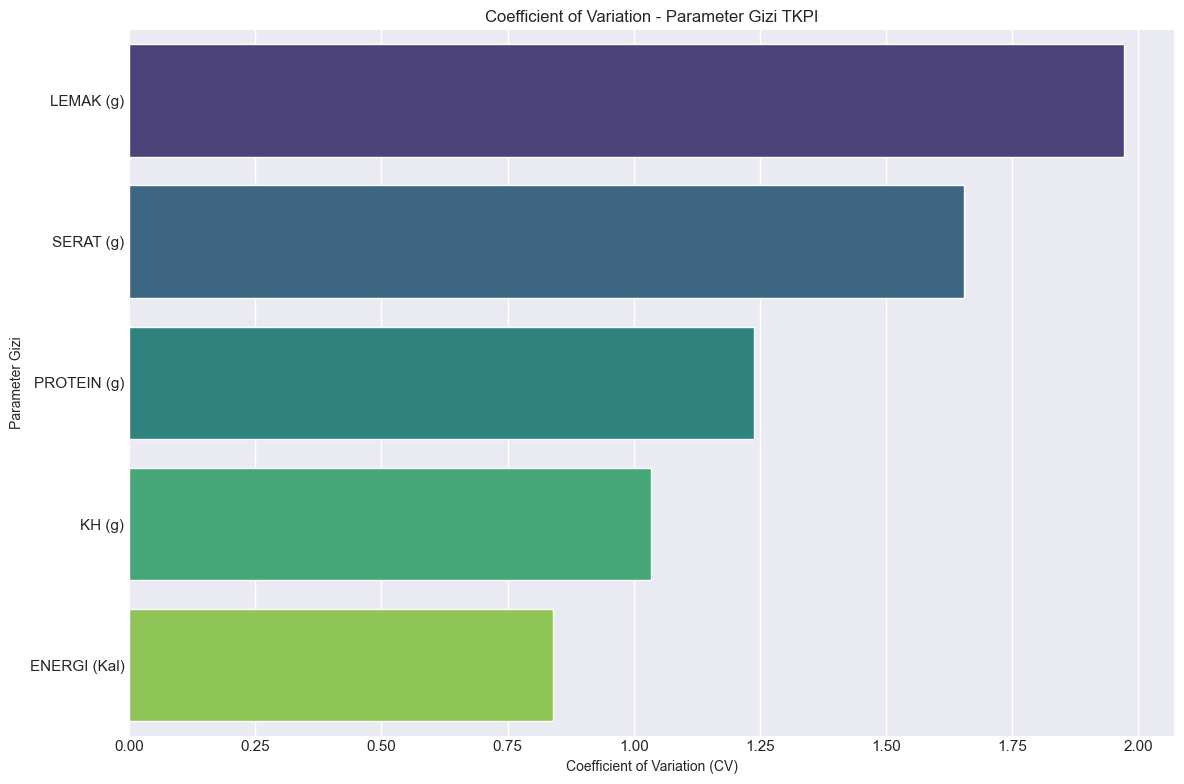

In [102]:
# ============================================================
# PERTANYAAN 1: PARAMETER GIZI PRIORITAS
# ============================================================

print("="*60)
print("PERTANYAAN 1: PARAMETER GIZI PRIORITAS")
print("="*60)

# Ambil semua kolom numerik dari TKPI (kecuali NAMA BAHAN dan SUMBER)
all_columns = df_tkpi_clean.columns.tolist()
exclude_cols = ['NAMA BAHAN', 'SUMBER']
numeric_cols = [col for col in all_columns if col not in exclude_cols]

print(f"\n[1] Total kolom numerik di TKPI: {len(numeric_cols)} kolom")
print(f"    Kolom yang akan dianalisis: {numeric_cols[:10]}...")

# Hitung statistik variasi untuk SEMUA kolom numerik
stats_df = df_tkpi_clean[numeric_cols].agg(['std', 'mean']).T
stats_df['cv'] = stats_df['std'] / stats_df['mean']  # coefficient of variation
stats_df = stats_df.sort_values('cv', ascending=False)

print("\n📊 Parameter dengan Variasi Tertinggi di TKPI (paling fleksibel untuk diatur):")
print(stats_df[['cv']].head(10).round(3))

# --- PRIORITAS BERDASARKAN LITERATUR GIZI ANAK SEKOLAH ---
# Gunakan nama kolom yang sesuai dengan dataset Anda
# Silakan sesuaikan nama kolom berikut dengan hasil pengecekan di atas

# Mapping nama kolom (sesuaikan dengan dataset Anda)
kolom_mapping = {
    'Energi': 'ENERGI (Kal)',  # Sesuaikan
    'Protein': 'PROTEIN (g)',  # Sesuaikan
    'Lemak': 'LEMAK (g)',      # Sesuaikan
    'KH': 'KH (g)',            # Sesuaikan
    'Serat': 'SERAT (g)',      # Sesuaikan
}

# Cek kolom yang tersedia
available_params = []
for key, col in kolom_mapping.items():
    if col in df_tkpi_clean.columns:
        available_params.append(col)
    else:
        print(f"⚠️ Kolom '{col}' tidak ditemukan, cari alternatif...")
        # Cari kolom dengan nama mirip
        similar = [c for c in df_tkpi_clean.columns if key.upper() in c.upper()]
        if similar:
            print(f"   → Gunakan '{similar[0]}' sebagai pengganti")
            available_params.append(similar[0])

print(f"\n✅ Parameter yang tersedia untuk analisis: {available_params}")

# Prioritas berdasarkan literatur (gunakan kolom yang tersedia)
prioritas_list = [
    ('ENERGI', 5, 'Penentu berat badan'),
    ('PROTEIN', 5, 'Pertumbuhan dan kenyang'),
    ('KH', 4, 'Sumber energi utama'),
    ('LEMAK', 4, 'Densitas energi'),
    ('SERAT', 4, 'Kontrol berat badan')
]

print("\n🎯 Rekomendasi Prioritas Parameter Gizi untuk Patokan:")
print("-" * 60)
for nama, score, alasan in prioritas_list:
    stars = '⭐' * score
    # Cari kolom yang sesuai
    matched_col = None
    for col in available_params:
        if nama in col.upper():
            matched_col = col
            break
    if matched_col:
        print(f"  {stars} {matched_col} (prioritas {score}/5) - {alasan}")
    else:
        print(f"  {stars} {nama} (prioritas {score}/5) - {alasan} [kolom tidak ditemukan]")

# Visualisasi CV parameter gizi (hanya yang valid)
if len(stats_df) > 0:
    plt.figure(figsize=(12, 8))
    top_n = min(15, len(stats_df))
    plot_data = stats_df.head(top_n)
    sns.barplot(x=plot_data['cv'].values, y=plot_data.index, palette='viridis')
    plt.title('Coefficient of Variation - Parameter Gizi TKPI', fontsize=12)
    plt.xlabel('Coefficient of Variation (CV)', fontsize=10)
    plt.ylabel('Parameter Gizi', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Tidak ada data untuk divisualisasikan")

### Pertanyaan 2: Variabel paling dominan mempengaruhi klasifikasi status gizi siswa?

PERTANYAAN 2: FITUR DOMINAN KLASIFIKASI STATUS GIZI

📊 Feature Importance (pengaruh terhadap status gizi):
  1. Berat Badan: 0.6434 (64.3%)
  2. Tinggi Badan: 0.2758 (27.6%)
  3. Usia: 0.0780 (7.8%)
  4. Jenis Kelamin: 0.0028 (0.3%)


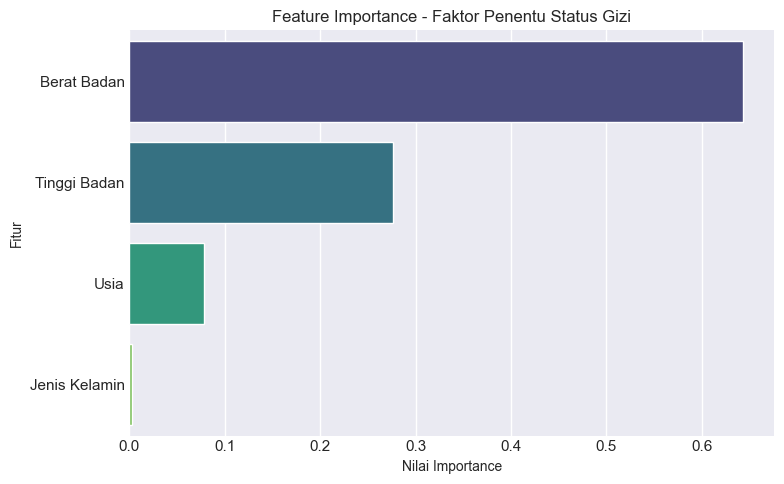


📊 Pengaruh Jenis Kelamin terhadap Status Gizi:
Status_Gizi  Normal  Obesity  Overweight  Underweight
Gender                                               
Laki-laki      61.5      0.4        30.0          8.1
Perempuan      60.5      0.4        30.8          8.4


In [104]:
# ============================================================
# PERTANYAAN 2: FITUR DOMINAN (FEATURE IMPORTANCE)
# ============================================================

print("="*60)
print("PERTANYAAN 2: FITUR DOMINAN KLASIFIKASI STATUS GIZI")
print("="*60)

# Persiapan data untuk feature importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(df_bmi_clean['Status_Gizi'])

# Fitur yang digunakan
features = ['Age', 'Gender_Encoded', 'Height', 'Weight']
X = df_bmi_clean[features]

# Train Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X, y_encoded)

# Feature importance
importances = rf.feature_importances_
feature_names = ['Usia', 'Jenis Kelamin', 'Tinggi Badan', 'Berat Badan']

# Urutkan importance
indices = np.argsort(importances)[::-1]

print("\n📊 Feature Importance (pengaruh terhadap status gizi):")
for i in range(len(feature_names)):
    print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f} ({importances[indices[i]]*100:.1f}%)")

# Visualisasi
plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
plt.title('Feature Importance - Faktor Penentu Status Gizi', fontsize=12)
plt.xlabel('Nilai Importance', fontsize=10)
plt.ylabel('Fitur', fontsize=10)
plt.tight_layout()
plt.show()

# Analisis pengaruh jenis kelamin
print("\n📊 Pengaruh Jenis Kelamin terhadap Status Gizi:")
gender_status = pd.crosstab(df_bmi_clean['Gender'], df_bmi_clean['Status_Gizi'], normalize='index') * 100
gender_status.index = gender_status.index.map({'P': 'Perempuan', 'L': 'Laki-laki'})
print(gender_status.round(1))

### Pertanyaan 3: Bentuk distribusi status gizi siswa?

PERTANYAAN 3: DISTRIBUSI STATUS GIZI

📊 Distribusi Status Gizi Siswa:
  - Underweight: 1984 siswa (8.2%)
  - Normal: 14704 siswa (61.0%)
  - Overweight: 7324 siswa (30.4%)
  - Obesity: 87 siswa (0.4%)

⚠️ SISWA PRIORITAS INTERVENSI (Underweight + Overweight + Obesity): 9395 siswa (39.0%)

📊 Kelompok Usia dengan Masalah Gizi Terbanyak:
Age_Group
Q3 (10-11 thn)    3357
Q1 (6-7 thn)      2498
Q4 (12 thn)       2172
Q2 (8-9 thn)      1368
dtype: int64


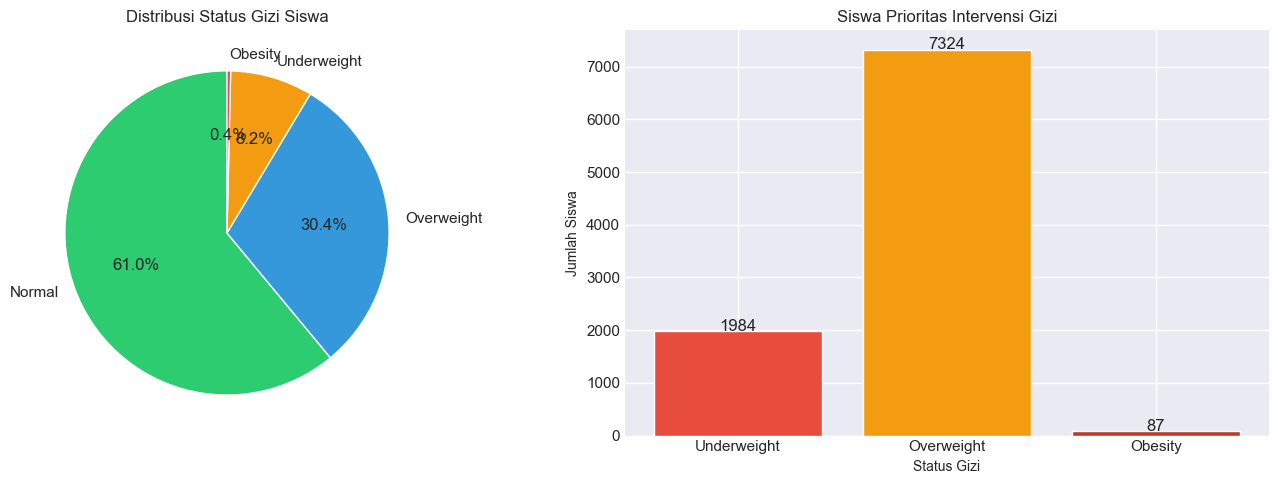


✅ KESIMPULAN:
   - 39.0% siswa memerlukan intervensi gizi prioritas
   - Kelompok usia dengan masalah terbanyak: Q3 (10-11 thn)
   - Normal: kelompok dengan proporsi terbesar


In [105]:
# ============================================================
# PERTANYAAN 3: DISTRIBUSI DAN PREVALENSI STATUS GIZI
# ============================================================

print("="*60)
print("PERTANYAAN 3: DISTRIBUSI STATUS GIZI")
print("="*60)

# Distribusi status gizi
status_counts = df_bmi_clean['Status_Gizi'].value_counts()
status_pct = df_bmi_clean['Status_Gizi'].value_counts(normalize=True) * 100

print("\n📊 Distribusi Status Gizi Siswa:")
for status in ['Underweight', 'Normal', 'Overweight', 'Obesity']:
    if status in status_counts:
        print(f"  - {status}: {status_counts[status]} siswa ({status_pct[status]:.1f}%)")
    else:
        print(f"  - {status}: 0 siswa (0.0%)")

# Intervensi prioritas (Underweight + Overweight + Obesity)
prioritas_count = status_counts.get('Underweight', 0) + status_counts.get('Overweight', 0) + status_counts.get('Obesity', 0)
prioritas_pct = (prioritas_count / len(df_bmi_clean)) * 100
print(f"\n⚠️ SISWA PRIORITAS INTERVENSI (Underweight + Overweight + Obesity): {prioritas_count} siswa ({prioritas_pct:.1f}%)")

# Kelompok usia prioritas
df_bmi_clean['Age_Group'] = pd.qcut(df_bmi_clean['Age'], q=4, labels=['Q1 (6-7 thn)', 'Q2 (8-9 thn)', 'Q3 (10-11 thn)', 'Q4 (12 thn)'])
age_priority = df_bmi_clean[df_bmi_clean['Status_Gizi'] != 'Normal'].groupby('Age_Group').size()
print("\n📊 Kelompok Usia dengan Masalah Gizi Terbanyak:")
print(age_priority.sort_values(ascending=False))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart status gizi
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Distribusi Status Gizi Siswa', fontsize=12)

# Bar plot intervensi prioritas
priority_data = ['Underweight', 'Overweight', 'Obesity']
priority_counts = [status_counts.get(s, 0) for s in priority_data]
bars = axes[1].bar(priority_data, priority_counts, color=['#e74c3c', '#f39c12', '#c0392b'])
axes[1].set_title('Siswa Prioritas Intervensi Gizi', fontsize=12)
axes[1].set_xlabel('Status Gizi', fontsize=10)
axes[1].set_ylabel('Jumlah Siswa', fontsize=10)
for bar, count in zip(bars, priority_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center')

plt.tight_layout()
plt.show()

print("\n✅ KESIMPULAN:")
print(f"   - {prioritas_pct:.1f}% siswa memerlukan intervensi gizi prioritas")
print(f"   - Kelompok usia dengan masalah terbanyak: {age_priority.idxmax()}")
print("   - Normal: kelompok dengan proporsi terbesar")

### Pertanyaan 4: Bahan pangan yang memiliki kandungan gizi yang cocok untuk menangani kasus?

PERTANYAAN 4: REKOMENDASI BAHAN PANGAN

✅ Kolom yang tersedia: ['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'KH (g)', 'SERAT (g)', 'LEMAK (g)']
✅ Total bahan pangan yang dianalisis: 952 bahan

🔺 REKOMENDASI UNTUK UNDERWEIGHT (Menaikkan Berat Badan)
   Prioritas: Energi Tinggi, Protein Tinggi
               NAMA BAHAN  ENERGI (Kal)  PROTEIN (g)  LEMAK (g)  KH (g)
              Minyak ikan         902.0          0.0      100.0     0.0
      Minyak kacang tanah         902.0          0.0      100.0     0.0
      Minyak kelapa sawit         884.0          0.0      100.0     0.0
            Minyak zaitun         884.0          0.0      100.0     0.0
           Minyak kedelai         883.0          0.0       99.9     0.0
             Minyak wijen         881.0          0.2       99.7     0.0
            Minyak kelapa         870.0          1.0       98.0     0.0
Lemak kerbau (lemak sapi)         818.0          1.5       90.0     0.0
                  Mentega         742.0          0.5      

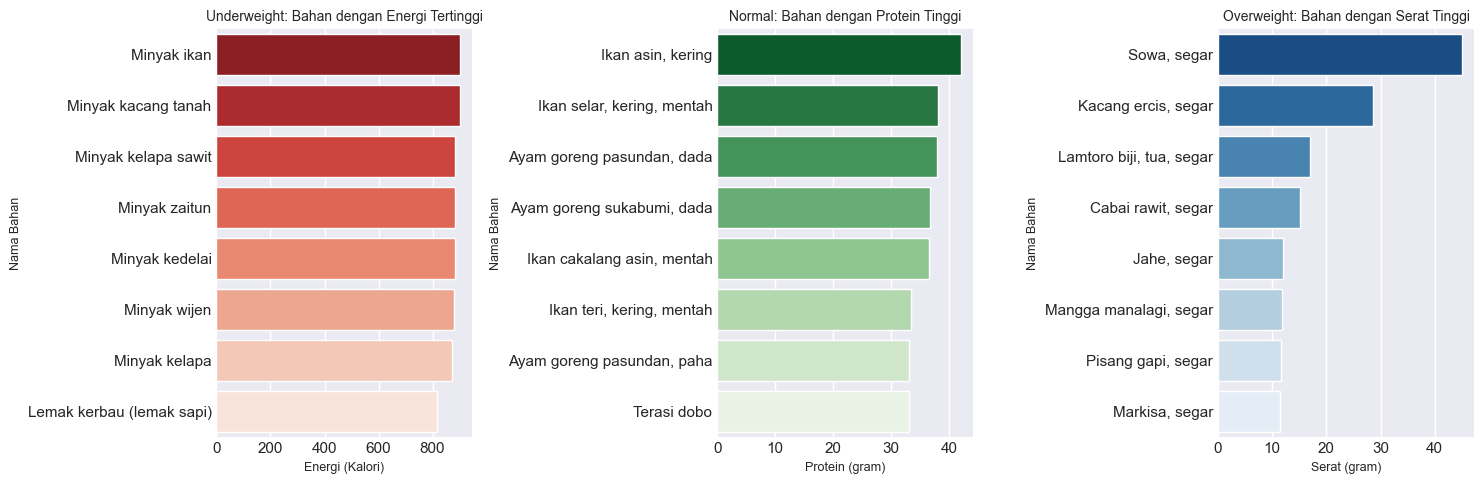

In [109]:
# ============================================================
# PERTANYAAN 4: REKOMENDASI GIZI BERDASARKAN TKPI
# ============================================================

print("="*60)
print("PERTANYAAN 4: REKOMENDASI BAHAN PANGAN")
print("="*60)

# Pastikan kolom yang diperlukan ada
required_cols = ['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'KH (g)', 'SERAT (g)', 'LEMAK (g)']
available_cols = [col for col in required_cols if col in df_tkpi_clean.columns]
print(f"\n✅ Kolom yang tersedia: {available_cols}")

# Filter bahan dengan nilai wajar (energi > 0)
df_tkpi_filtered = df_tkpi_clean[df_tkpi_clean['ENERGI (Kal)'] > 0].copy()
print(f"✅ Total bahan pangan yang dianalisis: {len(df_tkpi_filtered)} bahan")

# --- UNTUK UNDERWEIGHT (Tinggi Energi + Protein) ---
print("\n" + "="*60)
print("🔺 REKOMENDASI UNTUK UNDERWEIGHT (Menaikkan Berat Badan)")
print("   Prioritas: Energi Tinggi, Protein Tinggi")
print("="*60)

underweight_foods = df_tkpi_filtered.nlargest(10, 'ENERGI (Kal)')[['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'LEMAK (g)', 'KH (g)']]
print(underweight_foods.to_string(index=False))

# --- UNTUK NORMAL (Seimbang) ---
print("\n" + "="*60)
print("🟢 REKOMENDASI UNTUK NORMAL (Mempertahankan Berat Badan Ideal)")
print("   Prioritas: Gizi Seimbang, Protein cukup")
print("="*60)

normal_foods = df_tkpi_filtered[
    (df_tkpi_filtered['ENERGI (Kal)'] >= 100) & 
    (df_tkpi_filtered['ENERGI (Kal)'] <= 250) &
    (df_tkpi_filtered['PROTEIN (g)'] >= 5)
].nlargest(10, 'PROTEIN (g)')[['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'KH (g)', 'SERAT (g)']]

if len(normal_foods) < 5:
    # Fallback: ambil bahan dengan protein tinggi tanpa filter energi
    normal_foods = df_tkpi_filtered.nlargest(10, 'PROTEIN (g)')[['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'KH (g)', 'SERAT (g)']]

print(normal_foods.to_string(index=False))

# --- UNTUK OVERWEIGHT (Tinggi Serat, Rendah Energi) ---
print("\n" + "="*60)
print("🔻 REKOMENDASI UNTUK OVERWEIGHT (Menurunkan Berat Badan)")
print("   Prioritas: Serat Tinggi, Energi Rendah")
print("="*60)

overweight_foods = df_tkpi_filtered[
    (df_tkpi_filtered['ENERGI (Kal)'] <= 150)
].nlargest(10, 'SERAT (g)')[['NAMA BAHAN', 'ENERGI (Kal)', 'SERAT (g)', 'PROTEIN (g)', 'KH (g)']]

if len(overweight_foods) < 5:
    # Fallback: ambil bahan dengan serat tertinggi
    overweight_foods = df_tkpi_filtered.nlargest(10, 'SERAT (g)')[['NAMA BAHAN', 'ENERGI (Kal)', 'SERAT (g)', 'PROTEIN (g)', 'KH (g)']]

print(overweight_foods.to_string(index=False))

# --- VISUALISASI ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Underweight: Top energi
if len(underweight_foods) > 0:
    sns.barplot(data=underweight_foods.head(8), y='NAMA BAHAN', x='ENERGI (Kal)', ax=axes[0], palette='Reds_r')
    axes[0].set_title('Underweight: Bahan dengan Energi Tertinggi', fontsize=10)
    axes[0].set_xlabel('Energi (Kalori)', fontsize=9)
    axes[0].set_ylabel('Nama Bahan', fontsize=9)

# Normal: Top protein
if len(normal_foods) > 0:
    sns.barplot(data=normal_foods.head(8), y='NAMA BAHAN', x='PROTEIN (g)', ax=axes[1], palette='Greens_r')
    axes[1].set_title('Normal: Bahan dengan Protein Tinggi', fontsize=10)
    axes[1].set_xlabel('Protein (gram)', fontsize=9)
    axes[1].set_ylabel('Nama Bahan', fontsize=9)

# Overweight: Top serat
if len(overweight_foods) > 0:
    sns.barplot(data=overweight_foods.head(8), y='NAMA BAHAN', x='SERAT (g)', ax=axes[2], palette='Blues_r')
    axes[2].set_title('Overweight: Bahan dengan Serat Tinggi', fontsize=10)
    axes[2].set_xlabel('Serat (gram)', fontsize=9)
    axes[2].set_ylabel('Nama Bahan', fontsize=9)

plt.tight_layout()
plt.show()

### Pertanyaan 5: Performa model machine learning dalam klasifikasi?

PERTANYAAN 5: MODEL KLASIFIKASI

📊 Informasi Dataset:
  - Total sampel: 24099
  - Fitur yang digunakan: ['Age', 'Gender_Encoded', 'Height', 'Weight']
  - Target kelas: ['Normal', 'Obesity', 'Overweight', 'Underweight']
  - Distribusi kelas:
      Normal: 14704 (61.0%)
      Obesity: 87 (0.4%)
      Overweight: 7324 (30.4%)
      Underweight: 1984 (8.2%)

📊 Split Data:
  - Data Train: 19279 samples
  - Data Test: 4820 samples

📊 HASIL EVALUASI MODEL:
----------------------------------------------------------------------

  Decision Tree:
    - Test Accuracy: 0.9836
    - CV Mean: 0.9805 (+/- 0.0009)

  Random Forest:
    - Test Accuracy: 0.9846
    - CV Mean: 0.9823 (+/- 0.0014)

  Gradient Boosting:
    - Test Accuracy: 0.9776
    - CV Mean: 0.9751 (+/- 0.0009)

  SVM:
    - Test Accuracy: 0.9824
    - CV Mean: 0.9792 (+/- 0.0014)

🏆 MODEL TERBAIK: Random Forest dengan Accuracy 0.9846

📋 CLASSIFICATION REPORT - Random Forest:
              precision    recall  f1-score   support

     

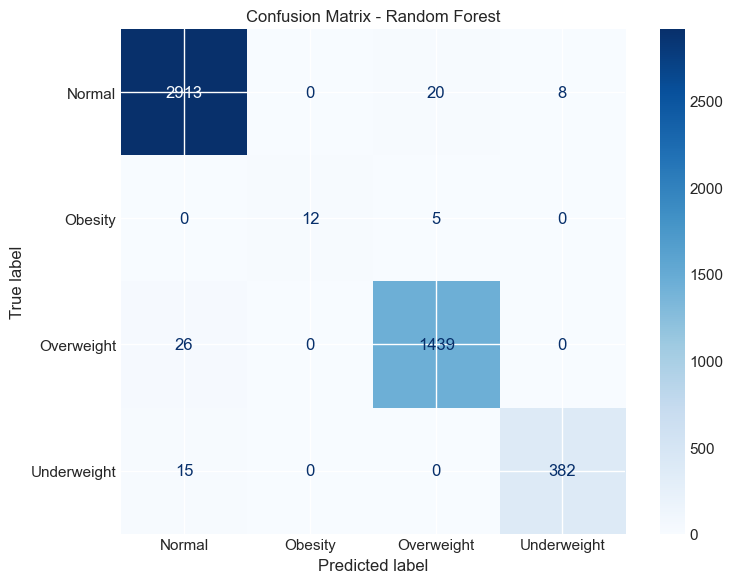

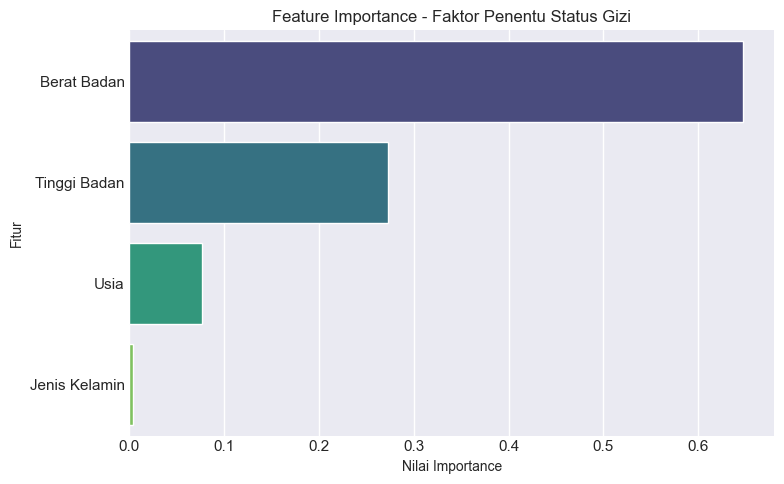


📊 Feature Importance (pengaruh terhadap status gizi):
  1. Berat Badan: 0.6476 (64.8%)
  2. Tinggi Badan: 0.2729 (27.3%)
  3. Usia: 0.0761 (7.6%)
  4. Jenis Kelamin: 0.0034 (0.3%)


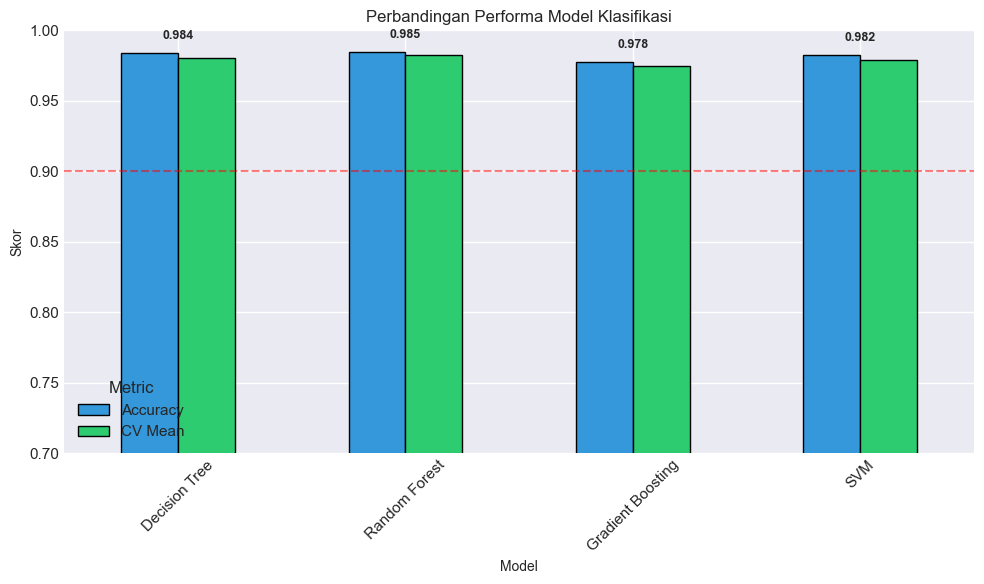


✅ KESIMPULAN MODEL KLASIFIKASI

   📌 Model Terbaik: Random Forest
      - Akurasi: 98.46%
      - Cross-validation: 98.23% (+/- 0.14%)



In [111]:
# ============================================================
# PERTANYAAN 5: MODEL KLASIFIKASI STATUS GIZI
# ============================================================

print("="*60)
print("PERTANYAAN 5: MODEL KLASIFIKASI")
print("="*60)

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Persiapan data
features = ['Age', 'Gender_Encoded', 'Height', 'Weight']
X = df_bmi_clean[features].copy()
y = df_bmi_clean['Status_Gizi'].copy()

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\n📊 Informasi Dataset:")
print(f"  - Total sampel: {len(X)}")
print(f"  - Fitur yang digunakan: {features}")
print(f"  - Target kelas: {list(le.classes_)}")
print(f"  - Distribusi kelas:")
for cls in le.classes_:
    count = (y == cls).sum()
    print(f"      {cls}: {count} ({count/len(y)*100:.1f}%)")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standardisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n📊 Split Data:")
print(f"  - Data Train: {X_train.shape[0]} samples")
print(f"  - Data Test: {X_test.shape[0]} samples")

# Model yang akan diuji
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

# Training dan evaluasi
results = {}
print("\n📊 HASIL EVALUASI MODEL:")
print("-" * 70)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'Accuracy': acc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    }
    
    print(f"\n  {name}:")
    print(f"    - Test Accuracy: {acc:.4f}")
    print(f"    - CV Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Model terbaik
best_model_name = max(results, key=lambda x: results[x]['Accuracy'])
best_model = models[best_model_name]
print(f"\n🏆 MODEL TERBAIK: {best_model_name} dengan Accuracy {results[best_model_name]['Accuracy']:.4f}")

# Classification Report model terbaik
y_pred_best = best_model.predict(X_test_scaled)
print(f"\n📋 CLASSIFICATION REPORT - {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=12)
plt.tight_layout()
plt.show()

# Feature Importance (khusus Random Forest)
if best_model_name == 'Random Forest':
    importances = best_model.feature_importances_
    feature_names = ['Usia', 'Jenis Kelamin', 'Tinggi Badan', 'Berat Badan']
    
    fig, ax = plt.subplots(figsize=(8, 5))
    indices = np.argsort(importances)[::-1]
    sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis', ax=ax)
    ax.set_title('Feature Importance - Faktor Penentu Status Gizi', fontsize=12)
    ax.set_xlabel('Nilai Importance', fontsize=10)
    ax.set_ylabel('Fitur', fontsize=10)
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Feature Importance (pengaruh terhadap status gizi):")
    for i in range(len(feature_names)):
        print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f} ({importances[indices[i]]*100:.1f}%)")

# Visualisasi perbandingan model
fig, ax = plt.subplots(figsize=(10, 6))
results_df = pd.DataFrame(results).T
results_df[['Accuracy', 'CV Mean']].plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71'], edgecolor='black')
ax.set_title('Perbandingan Performa Model Klasifikasi', fontsize=12)
ax.set_xlabel('Model', fontsize=10)
ax.set_ylabel('Skor', fontsize=10)
ax.set_ylim(0.7, 1.0)
ax.legend(title='Metric')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Threshold 90%')

# Tambahkan label nilai pada bar
for i, model_name in enumerate(results_df.index):
    acc_val = results_df.loc[model_name, 'Accuracy']
    ax.text(i, acc_val + 0.01, f'{acc_val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# --- KESIMPULAN AKHIR ---
print("\n" + "="*60)
print("✅ KESIMPULAN MODEL KLASIFIKASI")
print("="*60)
print(f"""
   📌 Model Terbaik: {best_model_name}
      - Akurasi: {results[best_model_name]['Accuracy']:.2%}
      - Cross-validation: {results[best_model_name]['CV Mean']:.2%} (+/- {results[best_model_name]['CV Std']:.2%})
""")

**Insight Explanatory:**
- 

## Membangun Model Klasifikasi (Cancel)

### 1. Persiapan Data untuk Model

In [15]:
if 'Gender_Encoded' not in df_bmi_clean.columns:
    df_bmi_clean['Gender_Encoded'] = df_bmi_clean['Gender'].map({'Pria': 1, 'Wanita': 0})

print(f"\nKolom yang tersedia: {df_bmi_clean.columns.tolist()}")

print("\nNilai unik di kolom Gender:")
print(df_bmi_clean['Gender'].unique())

print("\nNilai unik di kolom Gender_Encoded:")
print(df_bmi_clean['Gender_Encoded'].unique())

unique_gender = df_bmi_clean['Gender'].unique()
print(f"\nNilai Gender yang ditemukan: {unique_gender}")

gender_map = {}
for g in unique_gender:
    if g in ['Pria', 'Laki-laki', 'Male', 'L', '1']:
        gender_map[g] = 1
    elif g in ['Wanita', 'Perempuan', 'Female', 'P', '0']:
        gender_map[g] = 0
    else:
        gender_map[g] = -1  # tanda tidak dikenal

print(f"    Mapping: {gender_map}")

df_bmi_clean['Gender_Encoded'] = df_bmi_clean['Gender'].map(gender_map)

print(f"\n[4] Setelah mapping ulang:")
print(f"    Nilai unik Gender_Encoded: {df_bmi_clean['Gender_Encoded'].unique()}")
print(f"    Missing values: {df_bmi_clean['Gender_Encoded'].isnull().sum()}")

df_bmi_clean = df_bmi_clean[df_bmi_clean['Gender_Encoded'] != -1]
df_bmi_clean = df_bmi_clean.dropna(subset=['Gender_Encoded'])

print(f"\n[5] Shape akhir df_bmi_clean: {df_bmi_clean.shape}")


Kolom yang tersedia: ['Age', 'Gender', 'Height', 'Weight', 'BMI', 'Status_Gizi', 'Age_Group', 'Gender_Encoded']

Nilai unik di kolom Gender:
<ArrowStringArray>
['P', 'L']
Length: 2, dtype: str

Nilai unik di kolom Gender_Encoded:
[nan]

Nilai Gender yang ditemukan: <ArrowStringArray>
['P', 'L']
Length: 2, dtype: str
    Mapping: {'P': 0, 'L': 1}

[4] Setelah mapping ulang:
    Nilai unik Gender_Encoded: [0 1]
    Missing values: 0

[5] Shape akhir df_bmi_clean: (27922, 8)


In [16]:
print("\n[2] Nilai unik di kolom Gender_Encoded:")
print(df_bmi_clean['Gender_Encoded'].unique())

features = ['Age', 'Height', 'Weight', 'Gender_Encoded']
X = df_bmi_clean[features]
y = df_bmi_clean['Status_Gizi']

# Encoding target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Mapping Status Gizi:", dict(zip(le.classes_, le.transform(le.classes_))))

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standardisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data Train: {X_train.shape[0]} samples")
print(f"Data Test: {X_test.shape[0]} samples")
print(f"Jumlah kelas: {len(le.classes_)}")


[2] Nilai unik di kolom Gender_Encoded:
[0 1]
Mapping Status Gizi: {'Gemuk': np.int64(0), 'Kurus': np.int64(1), 'Normal': np.int64(2), 'Obesitas': np.int64(3)}
Data Train: 22337 samples
Data Test: 5585 samples
Jumlah kelas: 4


### 2. Membangun dan Evaluasi Model


Decision Tree
  Accuracy: 0.9893
  Precision: 0.9893
  Recall: 0.9893
  F1-Score: 0.9893

Random Forest
  Accuracy: 0.9882
  Precision: 0.9882
  Recall: 0.9882
  F1-Score: 0.9882

Gradient Boosting
  Accuracy: 0.9787
  Precision: 0.9786
  Recall: 0.9787
  F1-Score: 0.9786

SVM
  Accuracy: 0.9833
  Precision: 0.9834
  Recall: 0.9833
  F1-Score: 0.9820


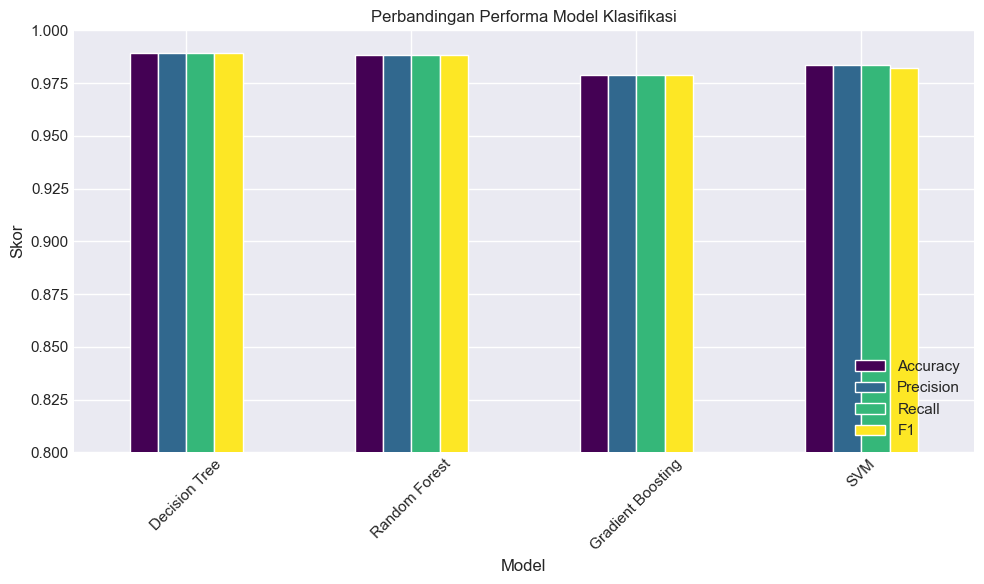

In [17]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

# Training dan evaluasi
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1': f1}
    
    print(f"\n{name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# Visualisasi perbandingan
results_df = pd.DataFrame(results).T
fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Perbandingan Performa Model Klasifikasi')
ax.set_xlabel('Model')
ax.set_ylabel('Skor')
ax.set_ylim(0.8, 1.0)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 3. Feature Importance


Feature Importance (pengaruh terhadap status gizi):
  1. Berat Badan: 0.6592 (65.9%)
  2. Tinggi Badan: 0.2683 (26.8%)
  3. Usia: 0.0696 (7.0%)
  4. Jenis Kelamin: 0.0029 (0.3%)


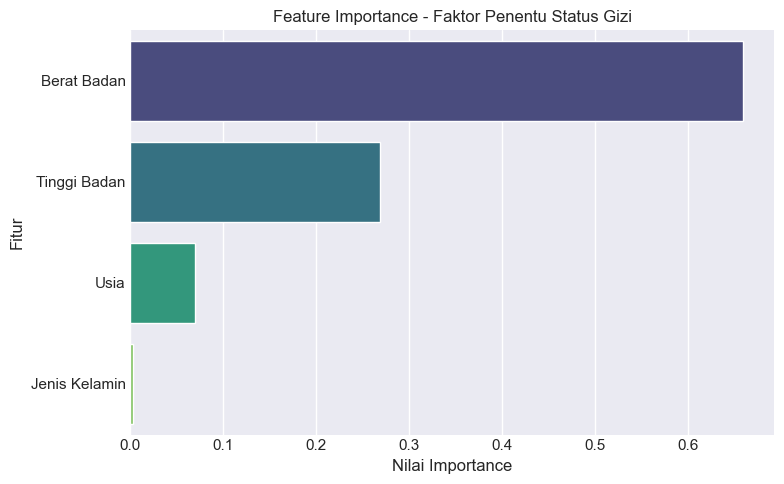

In [18]:
# Model terbaik untuk feature importance
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train_scaled, y_train)

importances = best_model.feature_importances_
feature_names = ['Usia', 'Tinggi Badan', 'Berat Badan', 'Jenis Kelamin']

indices = np.argsort(importances)[::-1]

print("\nFeature Importance (pengaruh terhadap status gizi):")
for i in range(len(feature_names)):
    print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f} ({importances[indices[i]]*100:.1f}%)")

# Visualisasi
plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
plt.title('Feature Importance - Faktor Penentu Status Gizi')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

### 4. Confusion Matrix Model Terbaik

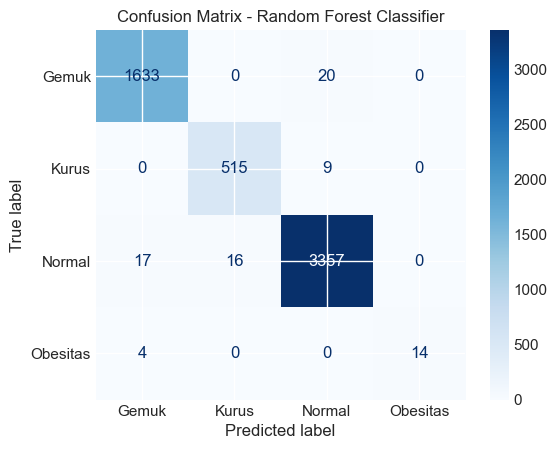


Classification Report:
              precision    recall  f1-score   support

       Gemuk       0.99      0.99      0.99      1653
       Kurus       0.97      0.98      0.98       524
      Normal       0.99      0.99      0.99      3390
    Obesitas       1.00      0.78      0.88        18

    accuracy                           0.99      5585
   macro avg       0.99      0.93      0.96      5585
weighted avg       0.99      0.99      0.99      5585



In [19]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

### 5. Hyperparameter Tuning

In [20]:
# Parameter grid untuk GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# GridSearch
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Evaluasi model tuned
y_pred_tuned = grid_search.predict(X_test_scaled)
print(f"Test Accuracy (Tuned): {accuracy_score(y_test, y_pred_tuned):.4f}")

# Simpan model terbaik
joblib.dump(grid_search.best_estimator_, 'best_model_classification.h5')
print("\nModel terbaik disimpan sebagai 'best_model_classification.h5'")

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Score: 0.9878
Test Accuracy (Tuned): 0.9884

Model terbaik disimpan sebagai 'best_model_classification.h5'


**Insight Model Klasifikasi:**
- 

## Mesin Rekomendasi Menu Berbasis Bahan Mentah (Cancel)

In [25]:
# Fungsi rekomendasi sederhana
def rekomendasi_kategori(kategori):
    if kategori == 'Underweight':
        # Bahan dengan energi dan protein tinggi
        rekomendasi = df_tkpi_clean.nlargest(8, 'ENERGI (Kal)')
        target_nutrisi = "Meningkatkan berat badan"
        saran = "Tingkatkan asupan kalori dan protein"
    elif kategori in ['Overweight', 'Obesity']:
        # Bahan dengan serat tinggi, kalori sedang
        rekomendasi = df_tkpi_clean.nlargest(8, 'SERAT (g)')
        target_nutrisi = "Mengontrol/Menurunkan berat badan"
        saran = "Kurangi kalori, perbanyak serat, dan protein tanpa lemak"
    else:  # Normal
        rekomendasi = df_tkpi_clean.sample(8)
        target_nutrisi = "Mempertahankan berat badan ideal"
        saran = "Pola makan seimbang sesuai AKG"
    
    return rekomendasi, target_nutrisi, saran

# Contoh rekomendasi untuk setiap kategori
for kategori in ['Underweight', 'Normal', 'Overweight', 'Obesity']:
    rekomendasi, target, saran = rekomendasi_kategori(kategori)
    print(f"\n{'='*50}")
    print(f"KATEGORI: {kategori}")
    print(f"Target: {target}")
    print(f"Strategi: {saran}")
    print(f"\nRekomendasi Bahan Makanan:")
    print(rekomendasi[['NAMA BAHAN', 'ENERGI (Kal)', 'PROTEIN (g)', 'SERAT (g)']].to_string(index=False))


KATEGORI: Underweight
Target: Meningkatkan berat badan
Strategi: Tingkatkan asupan kalori dan protein

Rekomendasi Bahan Makanan:
               NAMA BAHAN  ENERGI (Kal)  PROTEIN (g)  SERAT (g)
              Minyak ikan         902.0          0.0        0.0
      Minyak kacang tanah         902.0          0.0        0.0
      Minyak kelapa sawit         884.0          0.0        0.0
            Minyak zaitun         884.0          0.0        0.0
           Minyak kedelai         883.0          0.0        0.0
             Minyak wijen         881.0          0.2        0.0
            Minyak kelapa         870.0          1.0        0.0
Lemak kerbau (lemak sapi)         818.0          1.5        0.0

KATEGORI: Normal
Target: Mempertahankan berat badan ideal
Strategi: Pola makan seimbang sesuai AKG

Rekomendasi Bahan Makanan:
          NAMA BAHAN  ENERGI (Kal)  PROTEIN (g)  SERAT (g)
      Mie aceh rebus         113.0          3.0        NaN
          Cangkuning         204.0          2.8

**Insight Mesin Rekomendasi Menu:**
- 

## Kesimpulan Akhir

- **Kesimpulan pertanyaan 1:**
B

- **Kesimpulan pertanyaan 2:**
B

- **Kesimpulan pertanyaan 3:**
B

- **Kesimpulan pertanyaan 4:**
B

- **Kesimpulan pertanyaan 5:**
B

## Lainnya

In [42]:
import subprocess
import sys
from importlib.metadata import version, PackageNotFoundError

def generate_requirements():
    libraries = [
        'numpy',
        'pandas',
        'matplotlib',
        'seaborn',
        'scipy',
        'scikit-learn',
        'joblib',
        'streamlit'
    ]
    
    print("="*60)
    print("GENERATE REQUIREMENTS.TXT")
    print("="*60)
    
    requirements = []
    
    for lib in libraries:
        try:
            # Cek versi library yang terinstall
            ver = version(lib)
            requirements.append(f"{lib}=={ver}")
            print(f"{lib}=={ver}")
        except PackageNotFoundError:
            print(f"{lib} tidak terinstall")
    
    # Tulis ke file requirements.txt
    with open('requirements.txt', 'w') as f:
        f.write('\n'.join(requirements))
    
    print("\n" + "="*60)
    print(f"✅ requirements.txt berhasil dibuat!")
    print(f"   Total {len(requirements)} library")
    print("="*60)
    
    print("\n📄 Isi requirements.txt:")
    print("-" * 40)
    with open('requirements.txt', 'r') as f:
        print(f.read())

if __name__ == "__main__":
    generate_requirements()

GENERATE REQUIREMENTS.TXT
numpy==2.4.4
pandas==3.0.2
matplotlib==3.10.9
seaborn==0.13.2
scipy==1.17.1
scikit-learn==1.8.0
joblib==1.5.3
streamlit==1.57.0

✅ requirements.txt berhasil dibuat!
   Total 8 library

📄 Isi requirements.txt:
----------------------------------------
numpy==2.4.4
pandas==3.0.2
matplotlib==3.10.9
seaborn==0.13.2
scipy==1.17.1
scikit-learn==1.8.0
joblib==1.5.3
streamlit==1.57.0
